In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats


save_dir = Path("/Users/elizabethkaplan/Desktop/SS2_Results/time_resolved")

#load in time resolved data files for each subj
all_subjects = {}
for path in sorted(save_dir.glob("*_time_resolved.npz")):
    subj_id = path.name.replace("_time_resolved.npz", "")
    d = np.load(path, allow_pickle=True)
    all_subjects[subj_id] = {k: d[k] for k in d.files}
    all_subjects[subj_id]["window_stages"] = list(all_subjects[subj_id]["window_stages"])
    print(f"Loaded {subj_id}: {len(all_subjects[subj_id]['t_centers'])} windows")

Loaded 01-02-0001: 115821 windows
Loaded 01-02-0002: 140061 windows


In [9]:
## Characterize KC / Spindle temporal relationship 

#classify events based on the surrounding events within 3 sec +- 
relation_window = 3.0   # sec

all_relation_rows = []

for subj_id, d in all_subjects.items():
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]

    # classify each KC - before/after or isolated 
    for onset in kc_onsets:
        diffs = spindle_onsets - onset
        before = diffs[(diffs < 0) & (diffs >= -relation_window)]
        after  = diffs[(diffs > 0) & (diffs <=  relation_window)]

        if len(after) > 0:
            category = "kc_before_spindle"
        elif len(before) > 0:
            category = "kc_after_spindle"
        else:
            category = "kc_isolated"

        all_relation_rows.append({
            "subject":    subj_id,
            "event_type": "kc",
            "onset":      onset,
            "category":   category,
        })

    # classify spindles - before/after or isolated 
    for onset in spindle_onsets:
        diffs = kc_onsets - onset
        before = diffs[(diffs < 0) & (diffs >= -relation_window)]
        after  = diffs[(diffs > 0) & (diffs <=  relation_window)]

        if len(after) > 0:
            category = "spindle_before_kc"
        elif len(before) > 0:
            category = "spindle_after_kc"
        else:
            category = "spindle_isolated"

        all_relation_rows.append({
            "subject":    subj_id,
            "event_type": "spindle",
            "onset":      onset,
            "category":   category,
        })

relation_df = pd.DataFrame(all_relation_rows)

print("Event counts by category:")
print(relation_df["category"].value_counts())
print(f"\nTotal KCs:      {(relation_df['event_type']=='kc').sum()}")
print(f"Total spindles: {(relation_df['event_type']=='spindle').sum()}")

Event counts by category:
category
spindle_isolated     1759
kc_isolated           615
kc_before_spindle     251
spindle_before_kc     222
spindle_after_kc      206
kc_after_spindle      180
Name: count, dtype: int64

Total KCs:      1046
Total spindles: 2187


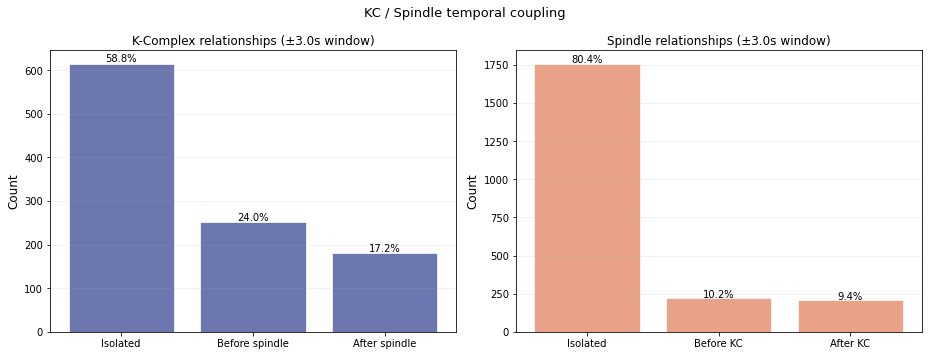

In [10]:
## Plot group counts 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kc_cats      = ["kc_isolated", "kc_before_spindle", "kc_after_spindle"]
spindle_cats = ["spindle_isolated", "spindle_before_kc", "spindle_after_kc"]
kc_labels      = ["Isolated", "Before spindle", "After spindle"]
spindle_labels = ["Isolated", "Before KC", "After KC"]

for ax, event_type, cats, labels, color in zip(
    axes,
    ["kc", "spindle"],
    [kc_cats, spindle_cats],
    [kc_labels, spindle_labels],
    ["#2c3e8c", "#e07b54"],
):
    sub = relation_df[relation_df["event_type"] == event_type]
    counts = [sub[sub["category"] == c].shape[0] for c in cats]
    pcts   = [100 * c / sum(counts) for c in counts]

    bars = ax.bar(labels, counts, color=color, alpha=0.7, edgecolor="white")
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{'K-Complex' if event_type=='kc' else 'Spindle'} relationships "
                 f"(±{relation_window}s window)", fontsize=12)
    ax.grid(True, alpha=0.2, axis="y")

    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{pct:.1f}%", ha="center", fontsize=10)

plt.suptitle("KC / Spindle temporal coupling", fontsize=13)
plt.tight_layout()
plt.show()

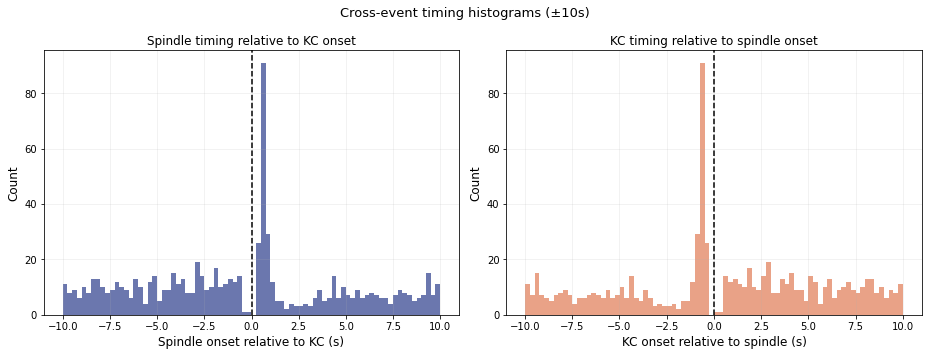

In [11]:
## Plot cross-event timing: when do spindles occur relative to KCs?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for subj_id, d in all_subjects.items():
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]

    # for each KC, find nearest spindle and record lag
    kc_to_spindle_lags = []
    for onset in kc_onsets:
        diffs = spindle_onsets - onset
        nearby = diffs[np.abs(diffs) <= 10.0]
        kc_to_spindle_lags.extend(nearby.tolist())

    spindle_to_kc_lags = []
    for onset in spindle_onsets:
        diffs = kc_onsets - onset
        nearby = diffs[np.abs(diffs) <= 10.0]
        spindle_to_kc_lags.extend(nearby.tolist())

axes[0].hist(kc_to_spindle_lags, bins=80, color="#2c3e8c", alpha=0.7, edgecolor="none")
axes[0].axvline(0, color="k", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Spindle onset relative to KC (s)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spindle timing relative to KC onset", fontsize=12)
axes[0].grid(True, alpha=0.2)

axes[1].hist(spindle_to_kc_lags, bins=80, color="#e07b54", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="k", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("KC onset relative to spindle (s)", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("KC timing relative to spindle onset", fontsize=12)
axes[1].grid(True, alpha=0.2)

plt.suptitle("Cross-event timing histograms (±10s)", fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
## Detect spindle trains

#train defined as events occuring within 6 seconds of one another *
train_window = 6.0
all_train_rows = []

for subj_id, d in all_subjects.items():
    spindle_onsets = np.sort(d["spindle_onsets"])
    
    if len(spindle_onsets) < 2:
        continue

    # assign each spindle to a train, then check for other spindles to group with it if meet temporal dynamics requirement (i.e.
    # within train_window 
    train_id   = 0
    train_ids  = [0]
    train_sizes = []

    for i in range(1, len(spindle_onsets)):
        gap = spindle_onsets[i] - spindle_onsets[i-1]
        if gap <= train_window:
            train_ids.append(train_id)
        else:
            train_id += 1
            train_ids.append(train_id)

    train_ids = np.array(train_ids)
    n_trains  = train_id + 1

    for tid in range(n_trains):
        members = np.where(train_ids == tid)[0]
        all_train_rows.append({
            "subject":       subj_id,
            "train_id":      tid,
            "n_spindles":    len(members),
            "onset":         spindle_onsets[members[0]],
            "offset":        spindle_onsets[members[-1]],
            "duration":      spindle_onsets[members[-1]] - spindle_onsets[members[0]],
            "is_train":      len(members) > 1,
        })

train_df = pd.DataFrame(all_train_rows)

print(f"Total spindle trains (groups): {len(train_df)}")
print(f"Isolated spindles (n=1):       {(train_df['n_spindles']==1).sum()}  "
      f"({100*(train_df['n_spindles']==1).mean():.1f}%)")
print(f"Actual trains (n≥2):           {(train_df['n_spindles']>1).sum()}  "
      f"({100*(train_df['n_spindles']>1).mean():.1f}%)")
print(f"\nTrain size distribution:")
print(train_df['n_spindles'].value_counts().sort_index())
print(f"\nMean spindles per train (trains only): "
      f"{train_df[train_df['is_train']]['n_spindles'].mean():.2f}")
print(f"Max spindles in one train: {train_df['n_spindles'].max()}")

Total spindle trains (groups): 1434
Isolated spindles (n=1):       963  (67.2%)
Actual trains (n≥2):           471  (32.8%)

Train size distribution:
n_spindles
1    963
2    299
3    100
4     47
5     17
6      5
7      2
9      1
Name: count, dtype: int64

Mean spindles per train (trains only): 2.60
Max spindles in one train: 9


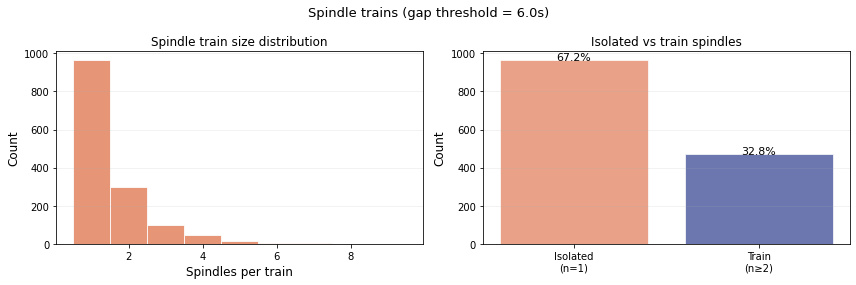

In [13]:
## Plot train info distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histogram of train sizes
axes[0].hist(train_df["n_spindles"], bins=range(1, train_df["n_spindles"].max()+2),
             color="#e07b54", alpha=0.8, edgecolor="white", align="left")
axes[0].set_xlabel("Spindles per train", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Spindle train size distribution", fontsize=12)
axes[0].grid(True, alpha=0.2, axis="y")

# isolated vs train
counts = [
    (train_df["n_spindles"] == 1).sum(),
    (train_df["n_spindles"] > 1).sum(),
]
axes[1].bar(["Isolated\n(n=1)", "Train\n(n≥2)"], counts,
            color=["#e07b54", "#2c3e8c"], alpha=0.7, edgecolor="white")
for i, (bar, count) in enumerate(zip(axes[1].patches, counts)):
    pct = 100 * count / sum(counts)
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f"{pct:.1f}%", ha="center", fontsize=11)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Isolated vs train spindles", fontsize=12)
axes[1].grid(True, alpha=0.2, axis="y")

plt.suptitle(f"Spindle trains (gap threshold = {train_window}s)", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
## Extract isolated events; event free on both sides
#investigate aperiodic dynamics in these event-free time points surrounding event 

isolation_window = 3.0   
pre_sec  = 3.0
post_sec = 3.0

n_bins  = int((pre_sec + post_sec) / step_sec)
t_event = np.linspace(-pre_sec, post_sec, n_bins)

kc_isolated_epochs      = []
spindle_isolated_epochs = []

for subj_id, d in all_subjects.items():
    t_centers      = d["t_centers"]
    exponent_clean = d["exponent_clean"]
    kc_onsets      = d["kc_onsets"]
    spindle_onsets = d["spindle_onsets"]
    combined       = np.sort(np.concatenate([kc_onsets, spindle_onsets]))

    # get isolated KCs 
    for onset in kc_onsets:
        # check no OTHER event within ±isolation_window
        other_events = combined[combined != onset]
        if np.any(np.abs(other_events - onset) <= isolation_window):
            continue

        # extract exponent in ±3s
        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask]

        if len(seg) != n_bins:
            continue
        if np.mean(np.isnan(seg)) > 0.2:
            continue

        kc_isolated_epochs.append(seg)

    # ── Isolated spindles ────────────────────────────────────────────────
    for onset in spindle_onsets:
        other_events = combined[combined != onset]
        if np.any(np.abs(other_events - onset) <= isolation_window):
            continue

        mask = (t_centers >= onset - pre_sec) & (t_centers < onset + post_sec)
        seg  = exponent_clean[mask]

        if len(seg) != n_bins:
            continue
        if np.mean(np.isnan(seg)) > 0.2:
            continue

        spindle_isolated_epochs.append(seg)

kc_isolated_epochs      = np.array(kc_isolated_epochs)
spindle_isolated_epochs = np.array(spindle_isolated_epochs)

print(f"Isolated KC epochs:      {len(kc_isolated_epochs)}")
print(f"Isolated spindle epochs: {len(spindle_isolated_epochs)}")

Isolated KC epochs:      462
Isolated spindle epochs: 1654


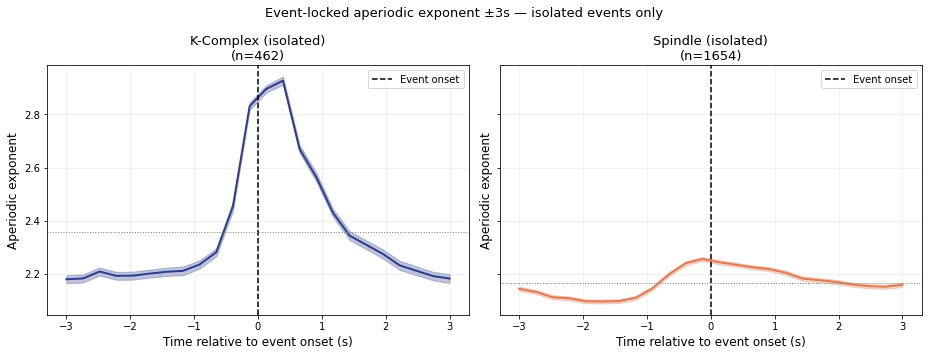

In [16]:
## Plot isolated event-locked exponent 

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, epochs, label, color in zip(
    axes,
    [kc_isolated_epochs, spindle_isolated_epochs],
    ["K-Complex (isolated)", "Spindle (isolated)"],
    ["#2c3e8c", "#e07b54"],
):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs, axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))

    ax.plot(t_event, mean, color=color, linewidth=2)
    ax.fill_between(t_event, mean - sem, mean + sem, alpha=0.3, color=color)
    ax.axvline(0, color="k", linestyle="--", linewidth=1.5, label="Event onset")
    ax.axhline(np.nanmean(mean), color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Time relative to event onset (s)", fontsize=12)
    ax.set_ylabel("Aperiodic exponent", fontsize=12)
    ax.set_title(f"{label}\n(n={len(epochs)})", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

plt.suptitle("Event-locked aperiodic exponent ±3s — isolated events only", fontsize=13)
plt.tight_layout()
plt.show()

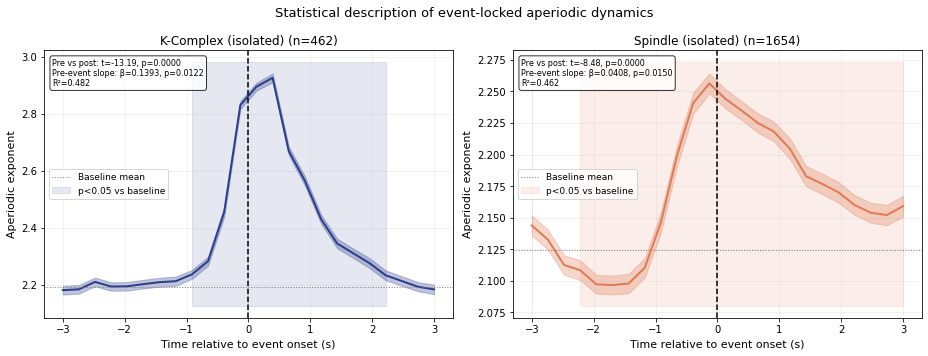

In [17]:
## Stats 

from scipy import stats
from scipy.stats import ttest_rel, ttest_1samp

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, epochs, label, color in zip(
    axes,
    [kc_isolated_epochs, spindle_isolated_epochs],
    ["K-Complex (isolated)", "Spindle (isolated)"],
    ["#2c3e8c", "#e07b54"],
):
    mean = np.nanmean(epochs, axis=0)
    sem  = np.nanstd(epochs, axis=0) / np.sqrt(np.sum(~np.isnan(epochs), axis=0))

    # ── 1. Pre vs post paired t-test ─────────────────────────────────────
    pre_mask  = t_event < 0
    post_mask = t_event >= 0
    pre_mean_per_epoch  = np.nanmean(epochs[:, pre_mask],  axis=1)
    post_mean_per_epoch = np.nanmean(epochs[:, post_mask], axis=1)
    t_prepost, p_prepost = ttest_rel(
        pre_mean_per_epoch[~np.isnan(pre_mean_per_epoch)],
        post_mean_per_epoch[~np.isnan(post_mean_per_epoch)],
    )

    # ── 2. Linear trend in pre-event window ──────────────────────────────
    pre_times = t_event[pre_mask]
    pre_mean  = mean[pre_mask]
    slope, intercept, r, p_slope, se = stats.linregress(pre_times, pre_mean)

    # ── 3. Baseline comparison — t-test at each time point ────────────────
    baseline_mask = (t_event >= -3.0) & (t_event < -2.0)
    baseline_vals = epochs[:, baseline_mask].mean(axis=1)  # per-epoch baseline mean
    baseline_vals = baseline_vals[~np.isnan(baseline_vals)]

    p_vals = []
    for ti in range(epochs.shape[1]):
        tp_vals = epochs[:, ti]
        tp_vals = tp_vals[~np.isnan(tp_vals)]
        if len(tp_vals) > 1:
            _, p = ttest_1samp(tp_vals, np.nanmean(baseline_vals))
        else:
            p = np.nan
        p_vals.append(p)
    p_vals = np.array(p_vals)

    # ── Plot mean ± SEM ───────────────────────────────────────────────────
    ax.plot(t_event, mean, color=color, linewidth=2)
    ax.fill_between(t_event, mean - sem, mean + sem, alpha=0.3, color=color)
    ax.axvline(0, color="k", linestyle="--", linewidth=1.5)
    ax.axhline(np.nanmean(mean[baseline_mask]), color="gray", linestyle=":", linewidth=1, label="Baseline mean")

    # shade significant time points
    sig_mask = p_vals < 0.05
    ax.fill_between(t_event, ax.get_ylim()[0], ax.get_ylim()[1],
                    where=sig_mask, alpha=0.12, color=color, label="p<0.05 vs baseline")

    # annotate stats
    ax.set_title(f"{label} (n={len(epochs)})", fontsize=12)
    ax.set_xlabel("Time relative to event onset (s)", fontsize=11)
    ax.set_ylabel("Aperiodic exponent", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

    textstr = (f"Pre vs post: t={t_prepost:.2f}, p={p_prepost:.4f}\n"
               f"Pre-event slope: β={slope:.4f}, p={p_slope:.4f}\n"
               f"R²={r**2:.3f}")
    ax.text(0.02, 0.97, textstr, transform=ax.transAxes,
            fontsize=8, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Statistical description of event-locked aperiodic dynamics", fontsize=13)
plt.tight_layout()
plt.show()